In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import pandas as pd
import pickle
import glob
import json
import hyp
from rdkit import Chem
from rdkit.Chem import QED

from rdkit.Chem import Descriptors
from rdkit.Chem import RDConfig
import sys
import os
sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

def penalized_logP(mol):
    """
    Logarithm of partition coefficient, penalized by cycle length and synthetic accessibility.

        
    The code are from torchdrug torchdrug/metrics/metric.py
    https://github.com/DeepGraphLearning/torchdrug/blob/6066fbd82360abb5f270cba1eca560af01b8cc90/torchdrug/metrics/metric.py#L84
    
    This version also supports smiles string and should return the exactly same plogp values as torchdrug.

    Parameters:
        # pred (PackedMolecule): molecules to evaluate
        smiles_list: smiles strings to evaluate


    """
    # statistics from ZINC250k
    logp_mean = 2.4570953396190123
    logp_std = 1.434324401111988
    sa_mean = 3.0525811293166134
    sa_std = 0.8335207024513095
    cycle_mean = 0.0485696876403053
    cycle_std = 0.2860212110245455

    # mol = Chem.MolFromSmiles(smiles)
    try:
        mol.UpdatePropertyCache()
        cycles = Chem.GetSymmSSSR(mol)
        if cycles:
            max_cycle = max([len(cycle) for cycle in cycles])
            cycle = max(0, max_cycle - 6)
        else:
            cycle = 0
        logp = Descriptors.MolLogP(mol)
        sa = sascorer.calculateScore(mol)
        logp = (logp - logp_mean) / logp_std
        sa = (sa - sa_mean) / sa_std
        cycle = (cycle - cycle_mean) / cycle_std
        score = logp - sa - cycle
    except Chem.AtomValenceException:
        score = -30
    return score


def read_pickles(reg):
    paths = glob.glob(f'./Experiments/{reg}')
    # files = [open(p, 'rb') for p in paths]
    # return [pickle.load(f) for f in files]
    rt = []
    for p in paths:
        f = open(p, 'rb')
        rt.append(pickle.load(f))
        f.close()
    return rt
        

def read_results(reg):
    episodes = read_pickles(f'*{reg}*_episodes.pickle')
    path = read_pickles(f'*{reg}*_path.pickle')
    args = read_pickles(f'*{reg}*_args.pickle')
    return episodes, path, args

def remove_invalid_reward(r, reward_fn = 'BDE_IP'):
    if reward_fn.lower() == 'BDE_IP'.lower():
        if r < 0.0:
            return 0.0
        if r > 3.0:
            return 0.0
        return r
    return r # for QED or plogp rewards

def get_reward_fn(episodes):
    if 'BDE' in episodes[0]['rewards']:
        reward_fn = 'BDE_IP'
    elif 'QED' in episodes[0]['rewards']:
        reward_fn = 'QED'
    elif 'plogp' in episodes[0]['rewards']:
        reward_fn = 'plogp'
    return reward_fn
        
def get_rewards(reg, last_n_episodes = 5, ignore_cache = False):

    cache_path = os.path.join('./Experiments/cache', f'.{reg}_rewards_cache.pickle')
    if os.path.isfile(cache_path) and not ignore_cache:
        print('reading cached smiles')
        with open(cache_path, 'rb') as f:
            rts = pickle.load(f)
            return rts
            
    episodes, path, args = read_results(reg)
    rewards = {}
    reward_fn = get_reward_fn(episodes)
    for e in episodes:
        for k, v in e['rewards'].items():
            rs = np.array(v[-last_n_episodes:])
            if k == 'reward':
                rs = np.clip(rs, a_min=0, a_max=3.5)
            rs = np.average(rs, axis=0)
            if k in rewards:
                for r in rs:
                    # print(r)
                    rewards[k].append(remove_invalid_reward(r, reward_fn))
            else :
                rewards[k] = list(rs)

    init_rewards = {}
    # print(len(path))
    for p in path:
        _, reward_path = p['last'][-1] # read the path in last episode
        for k, v in reward_path.items():
            if k in init_rewards:
                for init_r in v:
                    init_rewards[k].append(init_r[0])
            else :
                init_rewards[k] = []
                for init_r in v:
                    init_rewards[k].append(init_r[0])

    if not ignore_cache:
        print('reading cached smiles')
        with open(cache_path, 'wb') as f:
            pickle.dump((rewards, init_rewards), f, protocol=pickle.HIGHEST_PROTOCOL)
            
    return rewards, init_rewards
    
def read_mols_txt(path):
    with open(path, 'r') as file:
        ss = file.read().splitlines()
    mols = []
    for s in ss:
        try:
            m = Chem.MolFromSmiles(s)
            mols.append(m)
        except Exception as e:
            print(e)
    return mols
def calc_qeds(mols):
    qeds = []
    for m in mols:
        try:
            qeds.append(QED.qed(m))
        except Exception as e:
            print(e)
    return qeds

def calc_plogps(mols):
    plogps = []
    for m in mols:
        try:
            plogps.append(penalized_logP(m))
        except Exception as e:
            print(e)
    return plogps



In [16]:
rewards_zinc_qed_ind, init_rewards_zinc_qed_ind = get_rewards('ZincQEDIND')
# rewards_zinc_qed_ind['QED'].sort()
print(rewards_zinc_qed_ind['QED'][int(len(rewards_zinc_qed_ind['QED']) * 0.75)])
print(rewards_zinc_qed_ind['QED'][int(len(rewards_zinc_qed_ind['QED']) * 0.5)])

# for q in rewards_zinc_qed_ind['QED']:
#     print(f'{q:.3f}')

# for k, v in rewards_zinc_qed_ind.items():
#     print(k)
#     print(len(v))

# for k, v in init_rewards_zinc_qed_ind.items():
#     print(k)
#     print(len(v))
# for i in range(0,256):
#     print(f'mv ZincQEDIND_{i}_* ../Experiments')

reading cached smiles
0.9326918788239877
0.9285355506996817


In [ ]:
# rewards_zinc_plogp_ind, init_rewards_zinc_plogp_ind = get_rewards('ZincPlogPIND')
# rewards_zinc_plogp_ind['plogp'].sort()
print(rewards_zinc_plogp_ind['plogp'][int(len(rewards_zinc_plogp_ind['plogp']) * 0.75)])
print(rewards_zinc_plogp_ind['plogp'][int(len(rewards_zinc_plogp_ind['plogp']) * 0.5)])

for q in rewards_zinc_plogp_ind['plogp']:
    print(f'{q:.3f}')

# for k, v in rewards_zinc_plogp_ind.items():
#     print(k)
#     print(len(v))

# for k, v in init_rewards_zinc_plogp_ind.items():
#     print(k)
#     print(len(v))
# for i in range(0,256):
#     print(f'mv ZincQEDIND_{i}_* ../Experiments')

reading cached smiles
1024
reading cached smiles


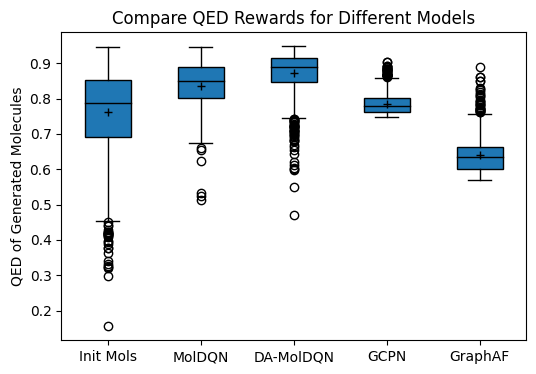

In [3]:

rewards, init_rewards = get_rewards('ZincQEDFT')
rewards['QED'].sort()
# print(rewards['QED'][int(len(rewards['QED']) * 0.75)])
# print(rewards['QED'][int(len(rewards['QED']) * 0.5)])
# print(len(rewards['QED']))


# for k, v in rewards.items():
#     print(k)
#     print(len(v))

# for k, v in init_rewards.items():
#     print(k)
#     print(len(v))


rewards_zinc_qed_ind, init_rewards_zinc_qed_ind = get_rewards('ZincQEDIND')
# rewards_zinc_qed_ind['QED'].sort()
# print(rewards_zinc_qed_ind['QED'][int(len(rewards_zinc_qed_ind['QED']) * 0.75)])
# print(rewards_zinc_qed_ind['QED'][int(len(rewards_zinc_qed_ind['QED']) * 0.5)])

# for q in rewards_zinc_qed_ind['QED']:
#     print(f'{q:.3f}')

# for k, v in rewards_zinc_qed_ind.items():
#     print(k)
#     print(len(v))

# for k, v in init_rewards_zinc_qed_ind.items():
#     print(k)
#     print(len(v))
# for i in range(0,256):
#     print(f'mv ZincQEDIND_{i}_* ../Experiments')

mols = read_mols_txt('./Data/RGCN_47000_qed_10epoch.txt')
rgcn_qeds = calc_qeds(mols)
# # print(rgcn_qeds)
rgcn_qeds.sort()
rgcn_qeds = rgcn_qeds[-1024:]

# rgcn_qeds.sort()
# print(rgcn_qeds[int(len(rgcn_qeds) * 0.75)])
# print(rgcn_qeds[int(len(rgcn_qeds) * 0.5)])


graphaf_mols = read_mols_txt('./Data/GraphAF_6400_qed_2epoch.txt')
graphaf_qeds = calc_qeds(graphaf_mols)
graphaf_qeds.sort()
# print(graphaf_qeds[int(len(graphaf_qeds) * 0.75)])
# print(graphaf_qeds[int(len(graphaf_qeds) * 0.5)])
graphaf_qeds = graphaf_qeds[-1024:]



# rgcn_rewards, rgcn_init_rewards = get_rewards('RGCNQEDFT')
# print(len(rgcn_init_rewards))

fig = plt.figure(figsize =(6, 4))
xt = np.arange(1,6,1)
# plt.ylim((-0.1, 2.25))
# ts =[init_rewards['reward'], rewards['reward'], rgcn_qeds, rgcn_init_rewards['reward'], rgcn_rewards['reward']]
ts =[init_rewards['reward'], rewards_zinc_qed_ind['QED'] ,rewards['reward'], rgcn_qeds, graphaf_qeds]
b1 = plt.boxplot(ts, positions=xt, showmeans=True, 
                 patch_artist=True, 
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )
plt.ylabel('QED of Generated Molecules')
plt.title('Compare QED Rewards for Different Models')
# plt.xticks(xt, ['Init Mols','DA-MolDQN','RGCN', 'RGCN Init', 'RGCN FT'])
plt.xticks(xt, ['Init Mols', 'MolDQN','DA-MolDQN','GCPN', 'GraphAF'])

# plt.xticks(rotation=45)
# plt.legend(handles=[b1['boxes'][0], b2['boxes'][0]], labels=['Numpy Fingerprint', 'List Fingerprint'])
# plt.savefig("./Results/Compare_Rewards_QED.png", dpi=500, bbox_inches = 'tight')
plt.show()


In [19]:
# mols = read_mols_txt('./Data/RGCN_4096_plogp_10epoch.txt')
# print(len(mols))
# # rgcn_plogp = calc_plogps(mols)
# print(len(rgcn_plogp))
# print(QED.qed(Chem.MolFromSmiles('CC(C)C(C)C')))
# print((rgcn_init_rewards['QED']))
# rgcn_qeds.sort()
# rgcn_init_rewards['QED'].sort()
# print(rgcn_qeds[:10])
# print(rgcn_init_rewards['QED'][:10])
import gc
gc.gc()

AttributeError: module 'gc' has no attribute 'gc'

reading cached smiles
reading cached smiles


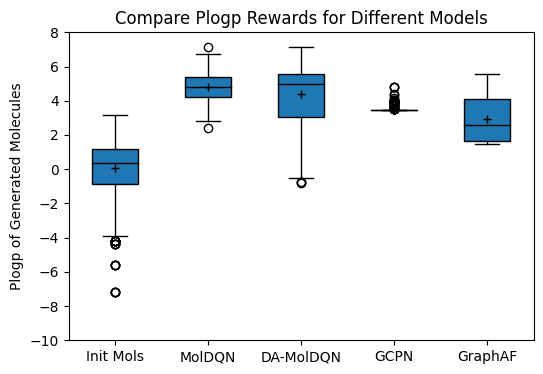

In [6]:
rewards, init_rewards = get_rewards('ZincPlogpFT')

# rewards['plogp'].sort()
# print(rewards['plogp'][-10:])
# print(rewards['plogp'][int(len(rewards['plogp']) * 0.75)])
# print(rewards['plogp'][int(len(rewards['plogp']) * 0.5)])

# for k, v in rewards.items():
#     print(k)
#     print(len(v))

# for k, v in init_rewards.items():
#     print(k)
#     print(len(v))

rewards_zinc_plogp_ind, init_rewards_zinc_plogp_ind = get_rewards('ZincPlogPIND')
rewards_zinc_plogp_ind['plogp'].sort()
# print(rewards_zinc_plogp_ind['plogp'][int(len(rewards_zinc_plogp_ind['plogp']) * 0.75)])
# print(rewards_zinc_plogp_ind['plogp'][int(len(rewards_zinc_plogp_ind['plogp']) * 0.5)])

# for q in rewards_zinc_plogp_ind['plogp']:
#     print(f'{q:.3f}')

mols = read_mols_txt('./Data/RGCN_18000_plogp_1epoch.txt')
rgcn_plogp = calc_plogps(mols)
# # print(rgcn_qeds)
rgcn_plogp.sort()
# print(rgcn_plogp[int(len(rgcn_plogp) * 0.75)])
# print(rgcn_plogp[int(len(rgcn_plogp) * 0.5)])
rgcn_plogp = rgcn_plogp[-1024:]



mols = read_mols_txt('./Data/GraphAF_6400_plogp_2epoch.txt')
graphaf_plogp = calc_plogps(mols)
# print(rgcn_qeds)
graphaf_plogp.sort()
# print(graphaf_plogp[int(len(graphaf_plogp) * 0.75)])
# print(graphaf_plogp[int(len(graphaf_plogp) * 0.5)])
graphaf_plogp = graphaf_plogp[-1024:]


fig = plt.figure(figsize =(6, 4))
xt = np.arange(1,6,1)
plt.ylim((-10, 8))
ts =[init_rewards['reward'], rewards_zinc_plogp_ind['reward'],rewards['reward'], rgcn_plogp, graphaf_plogp]
b1 = plt.boxplot(ts, positions=xt, showmeans=True, 
                 patch_artist=True, 
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )
plt.ylabel('Plogp of Generated Molecules')
plt.title('Compare Plogp Rewards for Different Models')
plt.xticks(xt, ['Init Mols', 'MolDQN','DA-MolDQN','GCPN', 'GraphAF'])
# plt.xticks(rotation=45)
# plt.legend(handles=[b1['boxes'][0], b2['boxes'][0]], labels=['Numpy Fingerprint', 'List Fingerprint'])
# plt.savefig("./Results/Compare_Rewards_Plogp.png", dpi=500, bbox_inches = 'tight')
plt.show()

In [25]:
f = open('./Experiments/ZincPlogp_1_1_episodes.pickle', 'rb')
p = pickle.load(f)
print(p.keys())
# print(np.array(p['rewards']['reward']).shape)
print(p['rewards'].keys())

# plt.plot(p['rewards']['reward'])
# plt.xlabel('Episode')
# plt.ylabel('rewards')
# plt.show()

# plt.title('Counts of Invalid 3D conformers in Parallel Models')


dict_keys(['batch_losses', 'episode_time', 'rewards', 'memory', 'lru_cache_hit_rate', 'lru_cache_ic_hit_rate', 'total_lru_cache_hit_rate', 'total_lru_cache_ic_hit_rate'])
dict_keys(['reward', 'plogp', 'sim'])


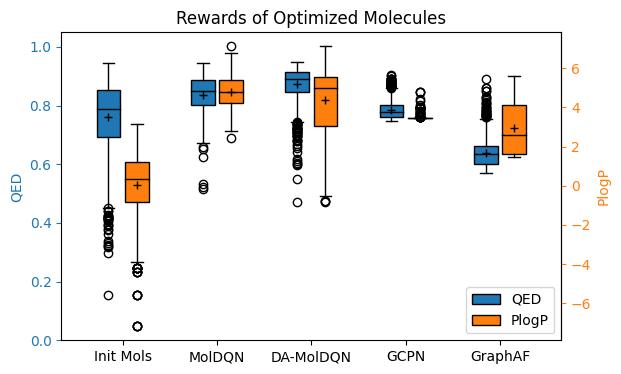

In [7]:

# rewards_qed, init_rewards_qed = get_rewards('ZincQEDFT')
# # rewards['QED'].sort()
# rewards_zinc_qed_ind, init_rewards_zinc_qed_ind = get_rewards('ZincQEDIND')

# mols = read_mols_txt('./Data/RGCN_47000_qed_10epoch.txt')
# rgcn_qeds = calc_qeds(mols)
# # # print(rgcn_qeds)
# rgcn_qeds.sort()
# rgcn_qeds = rgcn_qeds[-1024:]

# graphaf_mols = read_mols_txt('./Data/GraphAF_6400_qed_2epoch.txt')
# graphaf_qeds = calc_qeds(graphaf_mols)
# graphaf_qeds.sort()
# graphaf_qeds = graphaf_qeds[-1024:]


# rewards_plogp, init_rewards_plogp = get_rewards('ZincPlogpFT')
# rewards_zinc_plogp_ind, init_rewards_zinc_plogp_ind = get_rewards('ZincPlogPIND')
# rewards_zinc_plogp_ind['plogp'].sort()

# mols = read_mols_txt('./Data/RGCN_18000_plogp_1epoch.txt')
# rgcn_plogp = calc_plogps(mols)
# rgcn_plogp.sort()
# rgcn_plogp = rgcn_plogp[-1024:]

# mols = read_mols_txt('./Data/GraphAF_6400_plogp_2epoch.txt')
# graphaf_plogp = calc_plogps(mols)
# graphaf_plogp.sort()
# graphaf_plogp = graphaf_plogp[-1024:]

w = 0.25

fig, host = plt.subplots(figsize = (8, 4))
fig.subplots_adjust(right=0.75)

par1 = host.twinx()

xt = np.arange(1,6,1)
xt_qed = np.arange(0.85,5.85,1)
ts_qed =[init_rewards_qed['reward'], rewards_zinc_qed_ind['reward'] ,rewards_qed['reward'], rgcn_qeds, graphaf_qeds]
b_qed = host.boxplot(ts_qed, positions=xt_qed, showmeans=True, widths=[w for _ in np.arange(len(ts_qed))],
                 patch_artist=True, 
            boxprops={"facecolor":"C0","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )
xt_plogp = np.arange(1.15,6.15,1)
ts_plogp =[init_rewards_plogp['reward'], rewards_zinc_plogp_ind['reward'] ,rewards_plogp['reward'], rgcn_plogp, graphaf_plogp]
b_plogp = par1.boxplot(ts_plogp, positions=xt_plogp, showmeans=True, widths=[w for _ in np.arange(len(ts_plogp))],
                 patch_artist=True, 
            boxprops={"facecolor":"C1","edgecolor":"black"},
            medianprops={"color": "k"},
            meanprops={"marker":"+","markerfacecolor":"k","markeredgecolor":"k"}
           )

host.set_ylim(0, 1.05)
    
# par1.set_ylim(0, 1.05)
# par2.set_ylim(1, 65)

host.set_ylabel("QED")
par1.set_ylabel('PlogP')

# lines = [p1, p2]
# host.legend(lines, [l.get_label() for l in lines], loc = 'center right')

for ax in [par1]:
    ax.set_frame_on(True)
    ax.patch.set_visible(False)

    plt.setp(ax.spines.values(), visible=False)
    ax.spines["right"].set_visible(True)
    
host.yaxis.label.set_color("C0")
par1.yaxis.label.set_color("C1")

host.tick_params(axis='y', colors="C0")
par1.tick_params(axis='y', colors="C1")

plt.legend([b_qed["boxes"][0], b_plogp["boxes"][0]], 
           ['QED', 'PlogP'], 
           loc='lower right'
          )

# plt.title('Compare Optimized Molecules with Related Works')
plt.title('Rewards of Optimized Molecules')
plt.xticks(xt, ['Init Mols', 'MolDQN','DA-MolDQN','GCPN', 'GraphAF'])


# plt.savefig("./Results/Compare_Rewards_QED_PlogP.png", dpi=500, bbox_inches = 'tight')
plt.show()



In [35]:
def get_epoch_time(path):
    with open(path, 'rb') as f:
        a = pickle.load(f)
    a = a['computation_time']
    # return a[-1] - a[0]
    df = []
    for i in range(len(a) -1):
        df.append(a[i + 1] - a[i])
    # return np.average(df)
    return df

gcpn_qed = get_epoch_time('Experiments/gcpn_qed_dist_time.pickle')
print(gcpn_qed )
gcpn_plogp = get_epoch_time('Experiments/gcpn_plogp_dist_time.pickle')
print(gcpn_plogp)
graphaf_qed = get_epoch_time('Experiments/graphaf_qed_dist_time.pickle')
print(graphaf_qed )
graphaf_plogp = get_epoch_time('Experiments/graphaf_plogp_dist_time.pickle')
print(graphaf_plogp )

# print('--------')
# def get_comp_time(path):
#     with open(path, 'rb') as f:
#         a = pickle.load(f)
#     a = a['computation_time']
#     return a
# da_qed_train = get_comp_time('./Experiments/ZincQED_1_args.pickle')
# print(da_qed_train)
# da_qed_ft = 0.0
# for i in range(1024):
#     p = f'./Experiments/ZincQEDFT_{i}_args.pickle'
#     da_qed_ft += get_comp_time(p)
# # da_qed_ft = 
# print(da_qed_ft / 1024)
# print(da_qed_ft / 16)

# moldqn_qed = 0.0
# for i in range(256):
#     p = f'./Experiments/ZincQEDIND_{i}_args.pickle'
#     moldqn_qed += get_comp_time(p)
# print(moldqn_qed/256)
# print(moldqn_qed/16)

# print('-----------')
# da_plogp_train = get_comp_time('./Experiments/ZincPlogp_1_args.pickle')
# print(da_plogp_train)
# da_plogp_ft = 0.0
# for i in range(1024):
#     p = f'./Experiments/ZincPlogpFT_{i}_args.pickle'
#     da_plogp_ft += get_comp_time(p)
# print(da_plogp_ft / 1024)
# print(da_plogp_ft / 16)

# moldqn_plogp = 0.0
# for i in range(256):
#     p = f'./Experiments/ZincPlogPIND_{i}_args.pickle'
#     moldqn_plogp += get_comp_time(p)
# print(moldqn_plogp/256)
# print(moldqn_plogp/16)




[728.9552500247955, 431.6062445640564, 315.13137555122375, 309.598690032959, 309.4555652141571, 354.77557945251465, 324.87459444999695, 362.51581931114197, 320.15371656417847, 366.3208181858063]
[797.9820113182068, 559.0859267711639, 269.1529166698456, 212.51684403419495, 208.8933072090149, 200.26915955543518, 262.44727754592896, 193.27090644836426, 183.8247208595276, 232.11339783668518]
[568.8831121921539, 272.48538851737976, 274.38922452926636, 273.5931966304779, 274.3474049568176, 274.89507842063904, 275.3212311267853, 274.6789014339447, 274.9238407611847, 273.6246154308319]
[567.1009697914124, 271.4949917793274, 270.0055642127991, 270.5652575492859, 271.39049887657166, 270.813841342926, 271.8554792404175, 270.1037063598633, 270.4385471343994, 271.1323173046112]


init_rs:
1.1392498297063816
irs:
1.0564990988545988
prs:
1.1469557762998528
prs_8_list:
1.1604979659495596
prs_16_list:
1.2201954363273857
grs:
1.669723964963289
frs:
1.7438678236706873
reading cached smiles


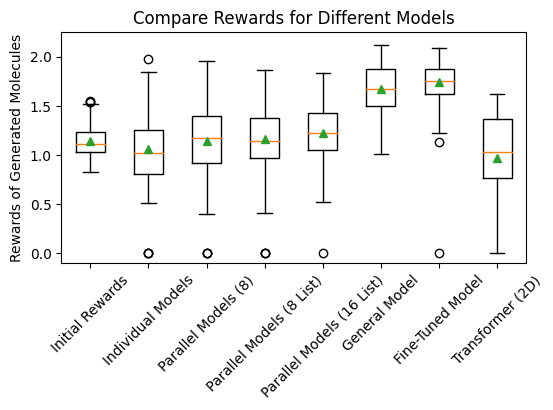

In [8]:
# without filter
trial = 573
world_size = 64
fine_tune_its = 2 # 5000 fine_tune iterations
num_mols = 256
average_episodes = 5

mols_per_rank = num_mols // world_size
topk = 0.3

def remove_invaild_reward(r):
#     return r
    if r < 0.0:
        return 0.0
    if r > 3.0:
        return 0.0
    return r
def add_reward(rs, path):
    reward_list = np.load(path)
    final_reward = np.array(reward_list[-average_episodes:])
    final_reward = np.average(final_reward, axis=0)
    for r in final_reward:
        rs.append(remove_invaild_reward(r))
        

# initial rewards
init_rs = []
for rank in range(world_size):
    path = './Experiments/trial_{}_rank_{}_initial_reward.pickle'.format(trial, rank)
    with open(path, 'rb') as f:
        init_rewards = pickle.load(f)
        for r in init_rewards:
            init_rs.append(r)
print("init_rs:")
print(np.average(init_rs))

# Independent rewards
irs = [] 
for i in range(num_mols):
    ft = '600{}'.format(i)
    path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, 0)
    add_reward(irs, path)
print("irs:")
print(np.average(irs))

# parallel model rewards， 8 mols
prs = []
for i in np.arange(0, 256, 8):
#     if i == 56:
#         continue
    ft = '800{}'.format(i)
    for r in range(8):
        path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, r)
        add_reward(prs, path)
print("prs:")
# print(prs)
print(np.average(prs))

# parallel model rewards, 16 mols
# prs16 = []
# for i in np.arange(0, 256, 16):
# #     if i == 56:
# #         continue
#     ft = '1600{}'.format(i)
#     for r in range(16):
#         path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, r)
#         add_reward(prs16, path)
# print("prs16:")
# # print(prs)
# print(np.average(prs16))

prs_8_list = []
for i in np.arange(0, 256, 8):
#     if i == 56:
#         continue
    ft = '2200{}'.format(i)
    for r in range(8):
        path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, r)
        add_reward(prs_8_list, path)
print("prs_8_list:")
# print(prs)
print(np.average(prs_8_list))

prs_16_list = []
for i in np.arange(0, 256, 16):
#     if i == 56:
#         continue
    ft = '2100{}'.format(i)
    for r in range(16):
        path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, r)
        add_reward(prs_16_list, path)
print("prs_16_list:")
# print(prs)
print(np.average(prs_16_list))

# general model rewards
grs = []
for rank in range(world_size):
    path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(trial, rank)
    add_reward(grs, path)

print("grs:")
print(np.average(grs))

# fine_tune rewards
frs = []
for i in range(num_mols):
    ft = '{}{}00{}'.format(trial, fine_tune_its, i)
    path = './Experiments/trial_{}_rank_{}_rewards.npy'.format(ft, 0)
    add_reward(frs, path)

print("frs:")
print(np.average(frs))

rewards_anti_ta, init_rewards_anti_ta = get_rewards('AntiTA')
rewards_anti_ta = rewards_anti_ta['reward']
init_rewards_anti_ta = init_rewards_anti_ta['reward']
# print(rewards_anti_ta)
# print(init_rewards_anti_ta)


# mrs = [max(g, f) for g, f in zip(grs, frs)]
# print("mrs:")
# print(np.average(mrs))

fig = plt.figure(figsize =(6, 3))
plt.ylim((-0.1, 2.25))
# plt.boxplot([init_rs, irs, prs, grs, frs, mrs], showmeans=True,
#             labels = ['Initial Rewards', 'Independent Models', 'Parallel Models', 'General Model (GM)',
#                       'Fine Tune (FT)', 'Max(GM, FT)'])
plt.boxplot([init_rs, irs, prs, prs_8_list, prs_16_list, grs, frs, rewards_anti_ta], showmeans=True,
            labels = ['Initial Rewards', 'Individual Models', 'Parallel Models (8)',
                      'Parallel Models (8 List)', 'Parallel Models (16 List)', 'General Model',
                      'Fine-Tuned Model', 'Transformer (2D)'])

plt.ylabel('Rewards of Generated Molecules')
plt.title('Compare Rewards for Different Models')
plt.xticks(rotation=45)
plt.savefig("./Results/Compare_Rewards_16_list_TA.png", dpi=500, bbox_inches = 'tight')
plt.show()


In [17]:
rewards_anti_ta, init_rewards_anti_ta = get_rewards('qedft3')
print(rewards_anti_ta)
# print(init_rewards_anti_ta)

IndexError: list index out of range

reading cached smiles
{'reward': [0.674267817912986, 0.880754742980425, 0.8499227653279389, 0.8838102797536898, 0.8079345290168771, 0.8814559314741386, 0.8511662666099502, 0.8056716962481028, 0.8292425215189662, 0.8262457619562278, 0.9286140647850688, 0.694626239660339, 0.8730161377280666, 0.7078531759641513, 0.8526426734395262, 0.9212371060787994, 0.8402656623980536, 0.8708763667672624, 0.8999662926083429, 0.7628001754593916, 0.779489910370463, 0.8112444097887683, 0.7634582510444226, 0.9308797220616121, 0.8158622440695037, 0.8177911911445287, 0.8203419990948063, 0.8895909498363348, 0.7880587055068209, 0.8183158066354391, 0.8705320061152179, 0.8598892305667828, 0.8547775145133236, 0.8432609869837264, 0.5823741924920427, 0.874248510599896, 0.6978786123720868, 0.30837052925330954, 0.8939250950738977, 0.921197132605321, 0.8498596526299143, 0.8227672540800359, 0.7453739893903316, 0.8998370986796671, 0.7421268886407337, 0.8184118332359148, 0.9181942392394365, 0.8102520377287485, 0.861511953

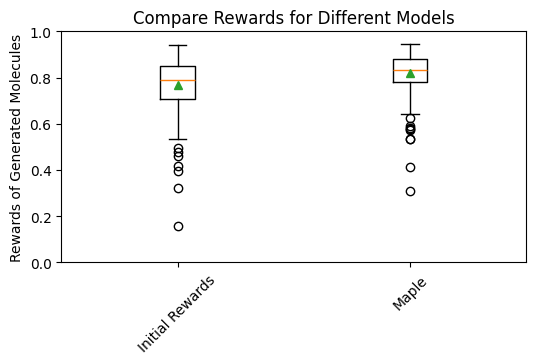

In [2]:

# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_5', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_5ft', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_qed_1', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('qedft2', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('zinc_qed', last_n_episodes=1, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('qedft3', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('ZincQEDFT')
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('ZincQED_1')
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('zinc_qed_6', last_n_episodes=5, ignore_cache = True)
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_qedtest3', last_n_episodes=1, ignore_cache = True)# good

# rewards_anti_ta, init_rewards_anti_ta = get_rewards('zinc_qed_9', last_n_episodes=5) # good
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_anti_0', last_n_episodes=5) # good
# rewards_anti_ta, init_rewards_anti_ta = get_rewards('maple_anti_1', last_n_episodes=5)
rewards_anti_ta, init_rewards_anti_ta = get_rewards('zinc_qed_10', last_n_episodes=5) # good

print(rewards_anti_ta)
# print(len(rewards_anti_ta['BDE']))
# for k, v in rewards_anti_ta.items():
#     print(f'{k}: {v[4]}')
# print(rewards_anti_ta['IP'])

rewards_anti_ta = rewards_anti_ta['reward']
init_rewards_anti_ta = init_rewards_anti_ta['reward']

# rs = []
# for r in rewards_anti_ta:
#     if r > 0:
#         rs.append(r)
# rewards_anti_ta = rs
# print(len(rewards_anti_ta))
# print(rewards_anti_ta)

fig = plt.figure(figsize =(6, 3))
# plt.ylim((-0.1, 2.25))
plt.ylim((0,1))
plt.boxplot([init_rewards_anti_ta, rewards_anti_ta], showmeans=True,
            labels = ['Initial Rewards',  'Maple'])

plt.ylabel('Rewards of Generated Molecules')
plt.title('Compare Rewards for Different Models')
plt.xticks(rotation=45)
plt.savefig("./Results/Compare_Rewards_Maple.png", dpi=500, bbox_inches = 'tight')
plt.show()


In [40]:
p = read_pickles('*maple_5_0_ep*')
# type(p)
# type(p[0])
# len(p)
for k, v in p[0].items():
    print(k)
# print(p[0]['rewards'])
print('-----------------------------')
rewards = p[0]['rewards']
type(rewards)
for k, v in rewards.items():
    print(k)
print('-----------------------------')
print(rewards['reward'][-5:])

batch_losses
episode_time
rewards
memory
bde_cache_hit_rate
ip_cache_hit_rate
total_bde_cache_hit_rate
total_ip_cache_hit_rate
-----------------------------
reward
BDE
IP
RRAB
IP_Probs
-----------------------------
[[0.8222916115539868, -0.1861716466220791, 1.1313965990166435, 0.55772004683366, 1.4368861540740776, 1.0158123991828398, 1.0474805151005595, 0.6110802187776166], [0.8082605672653438, -0.17896843282701194, 1.1743066411500103, 0.514414556490765, 1.459686485905892, 1.0610408543928704, 1.0903905572339263, 0.6173779313305284], [0.8225185576512226, -0.17800217995584258, 1.1199455497939437, 0.5237950463486136, 1.5839274949710354, 1.0442473266104757, 1.0360294658778597, 0.6035976167347378], [0.8093837415664937, -0.1762506666738888, 1.1760216110181405, 0.48809499069252366, -1000, 0.24209146247105087, 1.0921055271020566, 0.5974045484096032], [0.8690688358785528, -0.2006145425010352, 1.1695195045668438, 0.5474065681488305, -1000, 0.5349781462490744, 1.0856034206507599, 0.59415727511474

<class 'dict'>
batch_losses
episode_time
rewards
memory
bde_cache_hit_rate
ip_cache_hit_rate
total_bde_cache_hit_rate
total_ip_cache_hit_rate
-----------------------------
reward
QED
SA_score
-----------------------------
(2000,)
1981


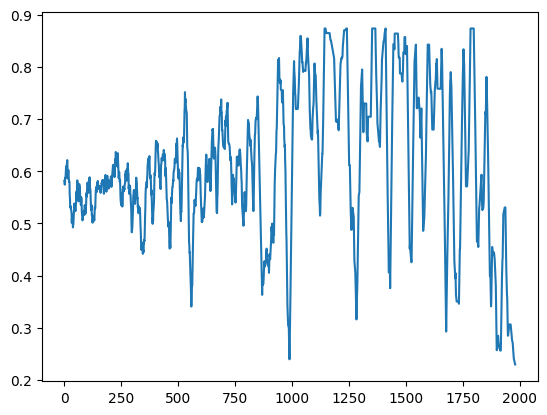

In [11]:
def movingaverage(interval, window_size):
    window = np.ones(int(window_size))/float(window_size)
    return np.convolve(interval, window, 'valid')
# p = read_pickles('qed_test_*episodes*')
p = read_pickles('*qedft3_0_*_episodes*')
print(type(p[0]))
for k, v in p[0].items():
    print(k)
print('-----------------------------')

rewards = p[0]['rewards']
type(rewards)
for k, v in rewards.items():
    print(k)
print('-----------------------------')
# print(rewards['QED'])

# rewards['QED']
r = rewards['QED']
r = np.array(r).reshape(-1)
print(r.shape)
r = movingaverage(r, window_size = 20)
print(len(r))
plt.plot(r)

# plt.xlabel("X Axis Label")
# plt.ylabel("Y Axis Label")
# plt.title("Simple Line Chart")

plt.show()


In [11]:
a = 0.999 ** 8000
# b = 0.5 * (x) ** 200 == a
x = pow(2*a, 1/2000)
x

0.9963512451986457

In [12]:
print(0.999 ** 8000)
print(0.968 ** 250)
print(0.5 * 0.996 ** 2000)

0.00033412256585375113
0.0002943332508135828
0.00016506190450003115


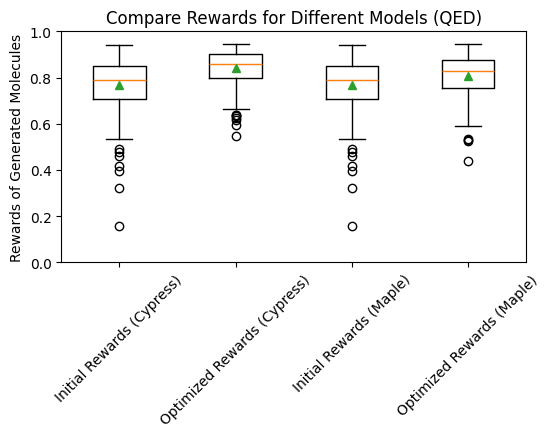

In [3]:

rewards_cypress, init_rewards_cypress = get_rewards('ZincQED_1', ignore_cache=True)
# rewards_maple, init_rewards_maple = get_rewards('zinc_qed_3',ignore_cache=True)
rewards_maple, init_rewards_maple = get_rewards('zinc_qed_9',ignore_cache=True)

rewards_cypress = rewards_cypress['reward']
init_rewards_cypress = init_rewards_cypress['reward']

rewards_maple = rewards_maple['reward']
init_rewards_maple = init_rewards_maple['reward']

fig = plt.figure(figsize =(6, 3))
# plt.ylim((-0.1, 2.25))
plt.ylim((0,1))
plt.boxplot([init_rewards_cypress, rewards_cypress, init_rewards_maple, rewards_maple], showmeans=True,
            labels = ['Initial Rewards (Cypress)',  'Optimized Rewards (Cypress)', 'Initial Rewards (Maple)', 'Optimized Rewards (Maple)'])

plt.ylabel('Rewards of Generated Molecules')
plt.title('Compare Rewards for Different Models (QED)')
plt.xticks(rotation=45)
plt.savefig("./Results/Compare_Rewards_Maple.png", dpi=500, bbox_inches = 'tight')
plt.show()


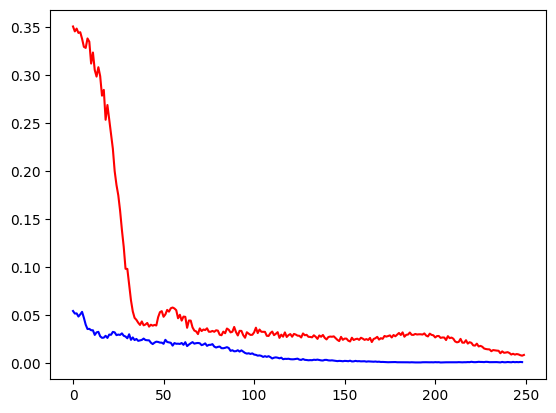

In [5]:
id = 30

p = read_pickles(f'ZincQED_1_{id}_episodes.pickle')
cypress_loss = p[0]['batch_losses']
p = read_pickles(f'zinc_qed_6_{id}_episodes.pickle')
maple_loss = p[0]['batch_losses']

plt.plot(cypress_loss, color='blue')
plt.plot(maple_loss,color='r')
plt.show()